Data Preparation

In [ ]:
import pandas as pd
import glob
import json

# Mengambil semua file yang berawalan 'StreamingHistory'
files = glob.glob("StreamingHistory*.json")
data_list = []

for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data_list.extend(json.load(f))

# Mengubah ke DataFrame
df = pd.DataFrame(data_list)
print(df.head())

            endTime      artistName                           trackName  \
0  2024-09-03 14:19          Weezer  Lost in the Woods - Weezer Version   
1  2025-04-25 07:59  The Stranglers                        Golden Brown   
2  2025-04-28 15:22       Big Thief                      Vampire Empire   
3  2025-04-29 05:01  The Stranglers                        Golden Brown   
4  2025-04-29 05:05           Suede                        Metal Mickey   

   msPlayed  
0    149834  
1     28111  
2     59226  
3    206760  
4    210924  


In [ ]:
df.isna().sum()

,0
endTime,0
artistName,0
trackName,0
msPlayed,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10121 entries, 0 to 10120
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   endTime     10121 non-null  object
 1   artistName  10121 non-null  object
 2   trackName   10121 non-null  object
 3   msPlayed    10121 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 316.4+ KB


In [ ]:
#Konversi waktu
df['endTime'] = pd.to_datetime(df['endTime'])

#Konversi msPlayed ke menit
df['minutesPlayed'] = df['msPlayed'] / 60000

# 3. Filter: Hanya ambil yang diputar lebih dari 10 detik (10.000 ms)
df = df[df['msPlayed'] > 10000]

# 4. Ekstrak informasi hari untuk analisis nanti
df['day'] = df['endTime'].dt.day_name()

# Daftar kata yang ingin dibuang secara spesifik
targets = ['Unknown Track', 'Unknown Artist']

df_clean = df[
    ~df['trackName'].isin(targets) &
    ~df['artistName'].isin(targets)
].copy()


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8707 entries, 0 to 10120
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   endTime        8707 non-null   datetime64[ns]
 1   artistName     8707 non-null   object        
 2   trackName      8707 non-null   object        
 3   msPlayed       8707 non-null   int64         
 4   minutesPlayed  8707 non-null   float64       
 5   day            8707 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 476.2+ KB


In [ ]:
df_clean.head()

,endTime,artistName,trackName,msPlayed,minutesPlayed,day
0,2024-09-03 14:19:00,Weezer,Lost in the Woods - Weezer Version,149834,2.497233,Tuesday
1,2025-04-25 07:59:00,The Stranglers,Golden Brown,28111,0.468517,Friday
2,2025-04-28 15:22:00,Big Thief,Vampire Empire,59226,0.987100,Monday
3,2025-04-29 05:01:00,The Stranglers,Golden Brown,206760,3.446000,Tuesday
4,2025-04-29 05:05:00,Suede,Metal Mickey,210924,3.515400,Tuesday


EDA

In [ ]:
#Total waktu mendengarkan dalam jam
total_minutes = df_clean['minutesPlayed'].sum() / 60
print("Total waktu mendengarkan: ", total_minutes, "jam")

Total waktu mendengarkan:  514.5554327777778 jam


Top 10 Artists:  artistName
Muse                   165199899
Panic! At The Disco    158715929
My Chemical Romance    122485033
Suede                  104469553
The Smiths              87977725
Duran Duran             69239713
David Bowie             63662499
Radiohead               43058865
Djo                     34517393
Green Day               33852421
Name: msPlayed, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Muse'),
  Text(1, 0, 'Panic! At The Disco'),
  Text(2, 0, 'My Chemical Romance'),
  Text(3, 0, 'Suede'),
  Text(4, 0, 'The Smiths'),
  Text(5, 0, 'Duran Duran'),
  Text(6, 0, 'David Bowie'),
  Text(7, 0, 'Radiohead'),
  Text(8, 0, 'Djo'),
  Text(9, 0, 'Green Day')])

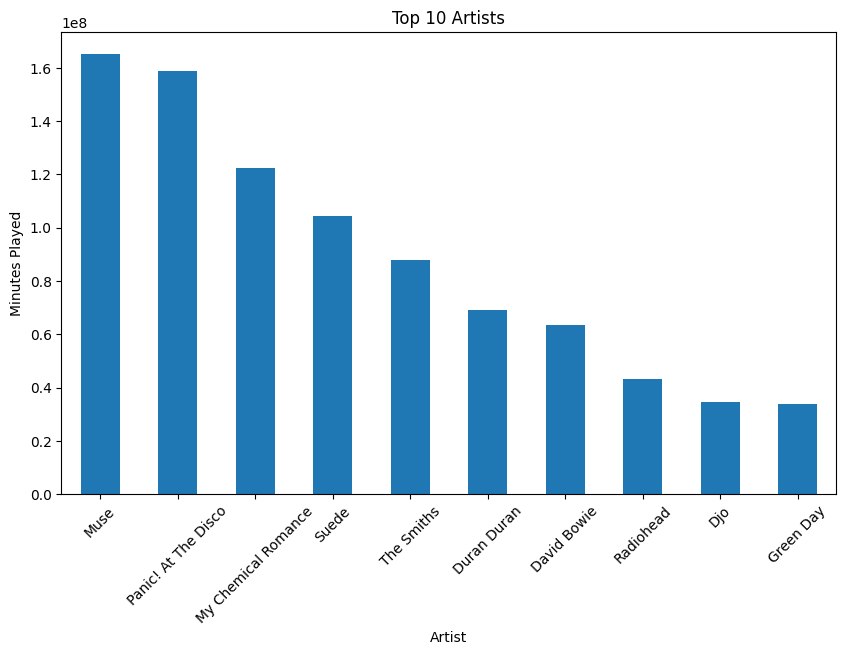

In [ ]:
#Siapa top artist yang paling sering didengarkan?
import matplotlib.pyplot as plt

top_artists = df_clean.groupby('artistName')['msPlayed'].sum().sort_values(ascending=False).head(10)
print("Top 10 Artists: ", top_artists)

plt.figure(figsize=(10, 6))
top_artists.plot(kind='bar')
plt.title('Top 10 Artists')
plt.xlabel('Artist')
plt.ylabel('Minutes Played')
plt.xticks(rotation=45)

Top 10 Songs:
 trackName
I Know It's Over - 2011 Remaster    17053527
The Crystal Lake                    13416154
Golden Brown                        11436697
Let Down                            11058466
How Soon Is Now? - 2011 Remaster    10908984
The Four Horsemen - Remastered      10582965
Paranoid Android                     9812166
A Night Like This                    9389570
Coloratura                           9330287
I'm Not In Love                      9215196
Name: msPlayed, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, "I Know It's Over - 2011 Remaster"),
  Text(1, 0, 'The Crystal Lake'),
  Text(2, 0, 'Golden Brown'),
  Text(3, 0, 'Let Down'),
  Text(4, 0, 'How Soon Is Now? - 2011 Remaster'),
  Text(5, 0, 'The Four Horsemen - Remastered'),
  Text(6, 0, 'Paranoid Android'),
  Text(7, 0, 'A Night Like This'),
  Text(8, 0, 'Coloratura'),
  Text(9, 0, "I'm Not In Love")])

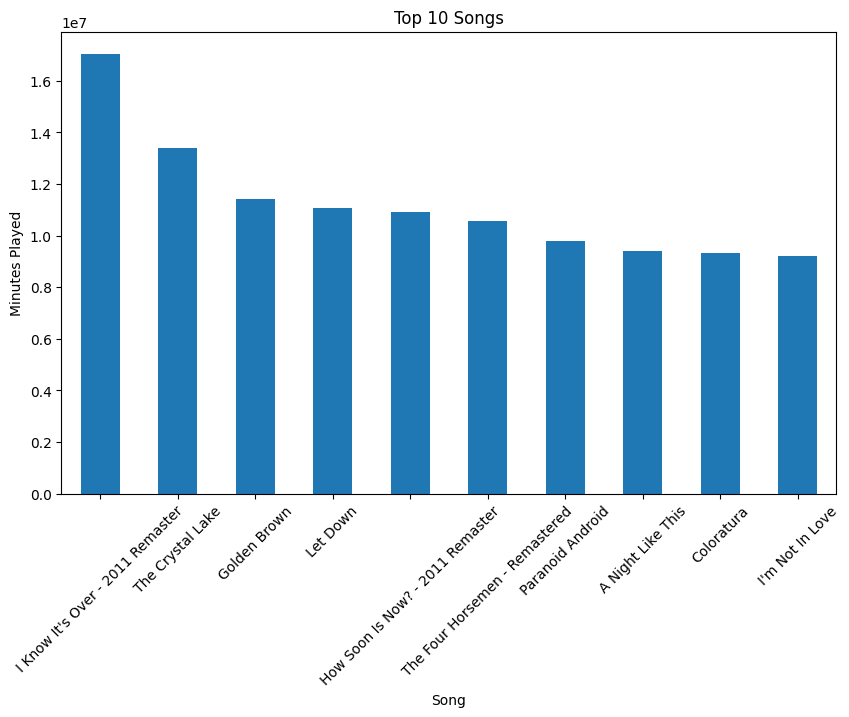

In [ ]:
# Apa lagu yang paling sering didengarkan?
top_songs = df_clean.groupby('trackName')['msPlayed'].sum().sort_values(ascending=False).head(10)
print("Top 10 Songs:\n", top_songs)

plt.figure(figsize=(10, 6))
top_songs.plot(kind='bar')
plt.title('Top 10 Songs')
plt.xlabel('Song')
plt.ylabel('Minutes Played')
plt.xticks(rotation=45)

In [ ]:
#Apakah perilaku mendengarku berubah saat hari libur?
# Cukup buat satu kolom dengan label yang jelas
df_clean['day_type'] = df_clean['day'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

# Sekarang groupby akan memunculkan teks 'Weekday' dan 'Weekend'
analisis_hari = df_clean.groupby('day_type')['minutesPlayed'].sum()
print(analisis_hari)

day_type
Weekday    21285.684200
Weekend     9587.641767
Name: minutesPlayed, dtype: float64


Join with Data from Kaggle (Audio Features)

In [ ]:
# 1. Load Dataset Kaggle
df_kaggle = pd.read_csv('/content/dataset.csv', on_bad_lines='skip')

# 2. Seleksi Kolom yang Diinginkan
# Kita ambil kolom identitas (artists & track_name) plus 5 fitur teknis
kolom_fitur = ['artists', 'track_name', 'danceability', 'energy', 'loudness', 'valence', 'tempo']
df_kaggle_subset = df_kaggle[kolom_fitur].copy()

# 3. Standardisasi String untuk Matching (Cleaning)
def clean_string(s):
    return str(s).lower().strip()

# Buat join_key di kedua DataFrame
df_clean['join_key'] = df_clean['artistName'].apply(clean_string) + " - " + df_clean['trackName'].apply(clean_string)
df_kaggle_subset['join_key'] = df_kaggle_subset['artists'].apply(clean_string) + " - " + df_kaggle_subset['track_name'].apply(clean_string)

# Hapus duplikat di data Kaggle agar tidak merusak jumlah baris data pribadi
df_kaggle_final = df_kaggle_subset.drop_duplicates(subset=['join_key'])

# 4. Gabungkan (Left Join)
# how='left' memastikan riwayat putarmu (df) tidak ada yang hilang
df_final = pd.merge(df_clean, df_kaggle_final, on='join_key', how='left')

# 5. Buang Kolom Bantuan & Format Waktu
df_final = df_final.drop(columns=['join_key', 'artists', 'track_name'])
df_final['endTime'] = pd.to_datetime(df_final['endTime'])

#6. Cek Hasil
print(f"Berhasil menggabungkan {len(df_final)} baris data.")
print(f"Data dengan fitur lengkap: {df_final['energy'].notnull().sum()}")
print(f"Data tanpa fitur: {df_final['energy'].isnull().sum()}")

Berhasil menggabungkan 8707 baris data.
Data dengan fitur lengkap: 2480
Data tanpa fitur: 6227


In [ ]:
# 7. Simpan Hasil Akhir
df_final.to_excel('spotify_tableau_ready.xlsx', index=False)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8707 entries, 0 to 8706
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   endTime        8707 non-null   datetime64[ns]
 1   artistName     8707 non-null   object        
 2   trackName      8707 non-null   object        
 3   msPlayed       8707 non-null   int64         
 4   minutesPlayed  8707 non-null   float64       
 5   day            8707 non-null   object        
 6   day_type       8707 non-null   object        
 7   danceability   2480 non-null   float64       
 8   energy         2480 non-null   float64       
 9   loudness       2480 non-null   float64       
 10  valence        2480 non-null   float64       
 11  tempo          2480 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 816.4+ KB


In [ ]:
df_final.head(10)

,endTime,artistName,trackName,msPlayed,minutesPlayed,day,day_type,danceability,energy,loudness,valence,tempo
0,2024-09-03 14:19:00,Weezer,Lost in the Woods - Weezer Version,149834,2.497233,Tuesday,Weekday,0.403,0.598,-5.735,0.294,75.592
1,2025-04-25 07:59:00,The Stranglers,Golden Brown,28111,0.468517,Friday,Weekday,0.562,0.383,-15.474,0.599,93.764
2,2025-04-28 15:22:00,Big Thief,Vampire Empire,59226,0.987100,Monday,Weekday,NaN,NaN,NaN,NaN,NaN
3,2025-04-29 05:01:00,The Stranglers,Golden Brown,206760,3.446000,Tuesday,Weekday,0.562,0.383,-15.474,0.599,93.764
4,2025-04-29 05:05:00,Suede,Metal Mickey,210924,3.515400,Tuesday,Weekday,NaN,NaN,NaN,NaN,NaN
5,2025-04-29 05:08:00,Panic! At The Disco,This Is Gospel,187186,3.119767,Tuesday,Weekday,NaN,NaN,NaN,NaN,NaN
6,2025-04-29 05:08:00,Nena,99 Luftballons,15137,0.252283,Tuesday,Weekday,0.636,0.467,-10.100,0.580,96.639
7,2025-04-29 05:09:00,ABBA,Voulez-Vous,59599,0.993317,Tuesday,Weekday,0.708,0.774,-6.931,0.903,126.636
8,2025-04-29 05:13:00,Panic! At The Disco,Do You Know What I'm Seeing?,254386,4.239767,Tuesday,Weekday,NaN,NaN,NaN,NaN,NaN
9,2025-04-29 05:17:00,Muse,Can't Take My Eyes off You,211120,3.518667,Tuesday,Weekday,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Mencari apakah masih ada kata 'unknown' di kolom artist atau track
check_unknown = df_final[
    df_final['trackName'].str.contains('Unknown Track', case=False, na=False) |
    df_final['artistName'].str.contains('Unknown Artist', case=False, na=False)
]

print(f"Jumlah baris yang masih mengandung kata 'unknown': {len(check_unknown)}")

if len(check_unknown) > 0:
    print("Contoh data yang masih ada:")
    print(check_unknown[['artistName', 'trackName']].head())
else:
    print("Mantap! Data sudah bersih dari kata 'unknown'.")

Jumlah baris yang masih mengandung kata 'unknown': 0
Mantap! Data sudah bersih dari kata 'unknown'.


Data Science: Song Recommendation Based on Listening History

In [ ]:
# Filter: Hanya ambil yang diputar lebih dari 10 detik (10.000 ms)
df = df[df['msPlayed'] > 10000]

# Daftar kata yang ingin dibuang secara spesifik
targets = ['Unknown Track', 'Unknown Artist']

df_clean2 = df[
    ~df['trackName'].isin(targets) &
    ~df['artistName'].isin(targets)
].copy()

In [ ]:
# Seleksi Kolom yang Diinginkan
kolom_fitur2 = ['artists', 'track_name', 'danceability', 'energy', 'loudness', 'valence', 'acousticness', 'instrumentalness', 'liveness',
               'speechiness', 'tempo', 'track_genre']
df_kaggle_subset2 = df_kaggle[kolom_fitur2].copy()

# Standardisasi String untuk Matching (Cleaning)
def clean_string(s):
    return str(s).lower().strip()

# Buat join_key di kedua DataFrame
df_clean2['join_key'] = df_clean2['artistName'].apply(clean_string) + " - " + df_clean2['trackName'].apply(clean_string)
df_kaggle_subset2['join_key'] = df_kaggle_subset2['artists'].apply(clean_string) + " - " + df_kaggle_subset2['track_name'].apply(clean_string)

# Hapus duplikat di data Kaggle agar tidak merusak jumlah baris data pribadi
df_kaggle_final2 = df_kaggle_subset2.drop_duplicates(subset=['join_key'])

# Gabungkan (Left Join)
# how='left' memastikan riwayat putarmu (df) tidak ada yang hilang
df_final2 = pd.merge(df_clean2, df_kaggle_final2, on='join_key', how='left')

# Buang Kolom Bantuan & Format Waktu
df_final2 = df_final2.drop(columns=['join_key', 'artists', 'track_name', 'endTime'])

# Cek Hasil
print(f"Berhasil menggabungkan {len(df_final2)} baris data.")
print(f"Data dengan fitur lengkap: {df_final2['energy'].notnull().sum()}")
print(f"Data tanpa fitur: {df_final2['energy'].isnull().sum()}")

Berhasil menggabungkan 8707 baris data.
Data dengan fitur lengkap: 2480
Data tanpa fitur: 6227


In [ ]:
df_history = df_final2.dropna()

In [ ]:
df_history.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2480 entries, 0 to 8705
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artistName        2480 non-null   object 
 1   trackName         2480 non-null   object 
 2   msPlayed          2480 non-null   int64  
 3   minutesPlayed     2480 non-null   float64
 4   day               2480 non-null   object 
 5   danceability      2480 non-null   float64
 6   energy            2480 non-null   float64
 7   loudness          2480 non-null   float64
 8   valence           2480 non-null   float64
 9   acousticness      2480 non-null   float64
 10  instrumentalness  2480 non-null   float64
 11  liveness          2480 non-null   float64
 12  speechiness       2480 non-null   float64
 13  tempo             2480 non-null   float64
 14  track_genre       2480 non-null   object 
dtypes: float64(10), int64(1), object(4)
memory usage: 310.0+ KB


In [ ]:
df_songs = df_kaggle.dropna()

In [ ]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          113999 

In [ ]:
# Ambil Numerical Features
fitur_numerik = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df_songs[fitur_numerik]

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
#Similarity Matrix
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(X_scaled)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
df_songs = df_songs.reset_index(drop=True)

In [ ]:
def recommend_songs(
    song_name,
    top_n=10,
    same_genre=True,
    exclude_history=True
):

    # Cari lagu di dataset
    matches = df_songs[
        df_songs['track_name'].str.lower() == song_name.lower()
    ]

    if matches.empty:
        return "Lagu tidak ditemukan di dataset."

    idx = matches.index[0]

    # Genre lagu acuan
    target_genre = df_songs.loc[idx, 'track_genre']

    # Lagu yang sudah pernah didengar
    if exclude_history:
        heard_songs = set(
            df_history['trackName']
            .astype(str)
            .str.lower()
        )
    else:
        heard_songs = set()

    # Cari kandidat lebih banyak dulu
    distances, indices = model.kneighbors(
        [X_scaled[idx]],
        n_neighbors=top_n * 5
    )

    recommendations = []

    for i, dist in zip(indices[0][1:], distances[0][1:]):

        candidate = df_songs.iloc[i]

        # Filter genre
        if same_genre:
            if candidate['track_genre'] != target_genre:
                continue

        # Hindari lagu yang sudah didengar
        if exclude_history:
            if candidate['track_name'].lower() in heard_songs:
                continue

        recommendations.append({
            'track_name': candidate['track_name'],
            'artist': candidate['artists'],
            'genre': candidate['track_genre'],
            'similarity_score': round(1 - dist, 3)
        })

        # Stop kalau sudah cukup
        if len(recommendations) == top_n:
            break

    if len(recommendations) == 0:
        return "Tidak ada rekomendasi yang memenuhi filter."

    return pd.DataFrame(recommendations)

In [ ]:
recommend_songs("Helena", same_genre=False)

,track_name,artist,genre,similarity_score
0,Outro Na Fornalha,Hillsong Em Português,gospel,0.988
1,your favorite dress,Lil Peep;Lil Tracy,emo,0.988
2,Um Milhão de Anos - Ao Vivo,Theo Rubia;AC Music,gospel,0.986
3,Um Milhão de Anos - Ao Vivo,Theo Rubia;AC Music,brazil,0.986
4,By Your Side,Sebastian Bach,hard-rock,0.984
5,Vitorioso És - ao vivo,Gabi Sampaio,gospel,0.982
6,Breaking Down,I Prevail,metalcore,0.981
7,Grande É o Senhor,Gabriel Brito,gospel,0.981
8,Abrazar la Niebla,Viernes Verde,metal,0.978
9,See The End,Above & Beyond;Seven Lions;Opposite the Other,trance,0.977


In [ ]:
top_tracks = (
    df_history['trackName']
    .value_counts()
    .head(10)
)

print(top_tracks)

trackName
Golden Brown                                      59
I Know It's Over - 2011 Remaster                  53
I Don't Wanna Be Me                               32
The Good Life                                     31
I'm Not In Love                                   31
How Soon Is Now? - 2011 Remaster                  28
Tonight, Tonight - Remastered 2012                28
Heaven Knows I'm Miserable Now - 2011 Remaster    27
Paranoid Android                                  27
Aerials                                           27
Name: count, dtype: int64


In [ ]:
favorite_song = top_tracks.index[5]
print("Your favorite song: ", favorite_song)
print("Song recommendations: ")
recommend_songs(favorite_song)

Your favorite song:  How Soon Is Now? - 2011 Remaster
Song recommendations: 


,track_name,artist,genre,similarity_score
0,Ajetaan tandemilla,Tyrävyö;Jimi Pääkallo,punk-rock,0.978
1,The Rock Show,blink-182,punk-rock,0.978
2,A Sua Assinatura,Matanza,punk-rock,0.972
3,Big Lizard,The Dead Milkmen,punk-rock,0.970
4,Partners in Crime (feat. Ash Costello),Set It Off;Ash Costello,punk-rock,0.969
